imports

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dataset path

In [2]:
DATASET_PATH = Path('../dataset/raw')

classes = [folder.name for folder in DATASET_PATH.iterdir() if folder.is_dir()]
classes

['Tomato__Bacterial_Spot',
 'Tomato__Early_Blight',
 'Tomato__Healthy',
 'Tomato__Late_Blight',
 'Tomato__Leaf_Mold',
 'Tomato__Mosaic_Virus',
 'Tomato__Septoria_Leaf_Spot',
 'Tomato__Target_Spot',
 'Tomato__Two_Spotted_Spider_Mites',
 'Tomato__YellowLeaf_Curl_Virus']

counting images per class

In [3]:
image_extensions = [".jpg", ".jpeg", ".png"]

data = []

for class_name in classes:
    class_path = DATASET_PATH / class_name

    # print(f"Processing class: {class_name}")
    # print(f"Class path: {class_path}")

    image_count = sum(
        1 for file in class_path.iterdir() 
        if file.suffix.lower() in image_extensions
    )
    data.append({
        "Class": class_name,
        "Image Count": image_count
    })

df = pd.DataFrame(data)
df

,Class,Image Count
0,Tomato__Bacterial_Spot,2127
1,Tomato__Early_Blight,1000
2,Tomato__Healthy,1591
3,Tomato__Late_Blight,1909
4,Tomato__Leaf_Mold,952
5,Tomato__Mosaic_Virus,373
6,Tomato__Septoria_Leaf_Spot,1771
7,Tomato__Target_Spot,1404
8,Tomato__Two_Spotted_Spider_Mites,1676
9,Tomato__YellowLeaf_Curl_Virus,3208


total images

In [4]:
total_images = df["Image Count"].sum()
print(f"Total number of images: {total_images}")

Total number of images: 16011


creating a display name mapping for better visualisation

In [5]:
display_names = {
    'Tomato__Bacterial_Spot': 'Bacterial Spot',
    'Tomato__Early_Blight': 'Early Blight',
    'Tomato__Healthy': 'Healthy',
    'Tomato__Late_Blight': 'Late Blight',
    'Tomato__Leaf_Mold': 'Leaf Mold',
    'Tomato__Mosaic_Virus': 'Mosaic Virus',
    'Tomato__Septoria_Leaf_Spot': 'Septoria Leaf Spot',
    'Tomato__Target_Spot': 'Target Spot',
    'Tomato__Two_Spotted_Spider_Mites': 'Spider Mites',
    'Tomato__YellowLeaf_Curl_Virus': 'Yellow Leaf Curl Virus'
}

df["Class"] = df["Class"].map(display_names)
print(df)

                    Class  Image Count
0          Bacterial Spot         2127
1            Early Blight         1000
2                 Healthy         1591
3             Late Blight         1909
4               Leaf Mold          952
5            Mosaic Virus          373
6      Septoria Leaf Spot         1771
7             Target Spot         1404
8            Spider Mites         1676
9  Yellow Leaf Curl Virus         3208


visualisation using horizontal bar chart

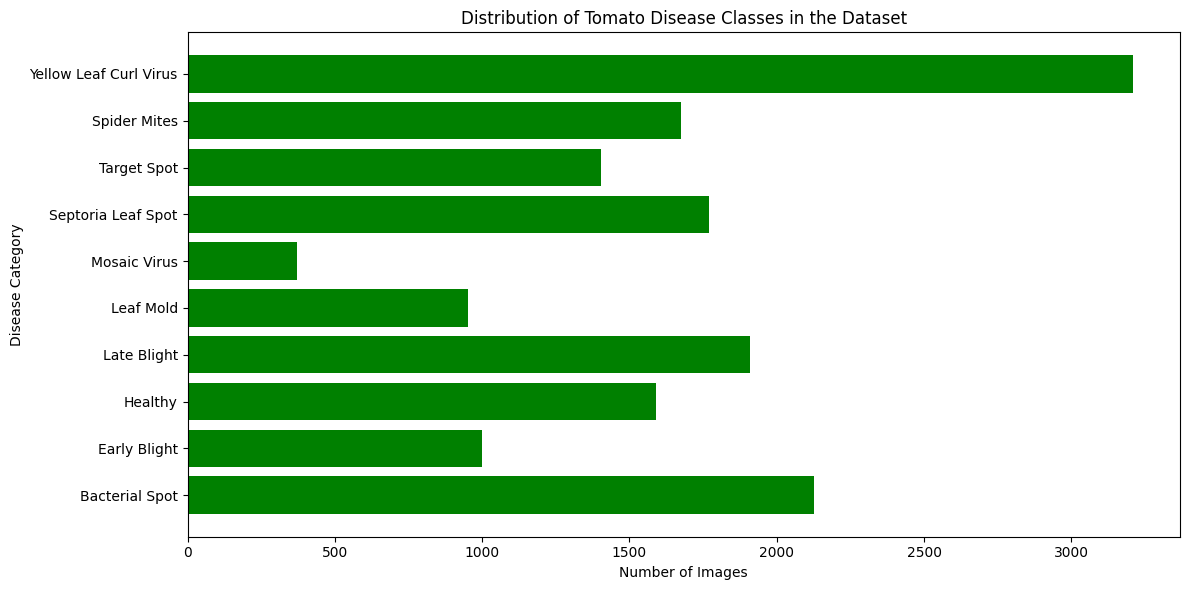

In [6]:
plt.figure(figsize=(12, 6))
plt.barh(
    df["Class"], 
    df["Image Count"], 
    color='green'
)
# plt.xticks(rotation=75, ha="right")
plt.ylabel("Disease Category")
plt.xlabel("Number of Images")
plt.title("Distribution of Tomato Disease Classes in the Dataset")
plt.tight_layout()
# saving the plot inside '../secreenshots/dataset' with name 'class_distribution.png'
plt.savefig("../screenshots/dataset/class_distribution.png", dpi=300)
plt.show()

dataset summary

In [7]:
summary = {
    "Total Classes": len(df),
    "Total Images": total_images,
    "Largest Class": df.loc[df["Image Count"].idxmax()]["Class"],
    "Largest Class Image Count": df["Image Count"].max(),
    "Smallest Class": df.loc[df["Image Count"].idxmin()]["Class"],
    "Smallest Class Image Count": df["Image Count"].min(),
    "Average Images per Class": round(df["Image Count"].mean(), 2)
}
summary_df = pd.DataFrame([summary])
summary_df

,Total Classes,Total Images,Largest Class,Largest Class Image Count,Smallest Class,Smallest Class Image Count,Average Images per Class
0,10,16011,Yellow Leaf Curl Virus,3208,Mosaic Virus,373,1601.1


class imbalance ratio = 3208 / 373 = 8.6
i.e. Largest class is 8.6 times bigger than the smallest class.
Potential issue:
The model may become very good at Yellow Leaf Curl Virus, 
but weaker at Mosaic Virus